In [34]:
import polars as pl
import pandas as pd
import numpy as np
from plotnine import *

## Resumen del Capítulo: Diseños Experimentales Alternativos al A/B Testing

En este capítulo se aborda cómo diseñar experimentos cuando el A/B testing tradicional no es viable, especialmente en contextos donde no es posible aleatorizar individuos (por ejemplo, clientes potenciales en marketing).

### 1. Del uso de datos panel al diseño experimental

En la Parte IV se trabajó con **datos panel** para estimar efectos causales a partir de observaciones repetidas en el tiempo. Sin embargo, ahora el enfoque cambia: en lugar de asumir que los datos ya existen, el objetivo es **diseñar un experimento que genere esos datos** de forma adecuada.

### 2. Geo-experimentos

Ante la dificultad de medir la incrementalidad del marketing (ya que la atribución no implica causalidad), se propone como alternativa el uso de **geo-experimentos**:

- Se asigna el tratamiento a mercados completos (ciudades o estados).
- Otros mercados funcionan como grupo de control.
- Esto permite construir datos panel a nivel geográfico.
- Luego se aplican técnicas de inferencia causal sobre esos datos.

El capítulo explica cómo seleccionar correctamente las unidades geográficas tratadas y de control para aproximar el efecto que se obtendría si todo el mercado fuera tratado.

**Ventaja:** Permite estimar incrementalidad real.  
**Desventaja:** Reduce el tamaño de muestra, ya que hay menos ciudades que clientes.

### 3. Limitaciones prácticas

En algunos casos, ni siquiera es posible aleatorizar múltiples mercados. Por ejemplo:

- Empresas pequeñas que operan en una sola ciudad.
- Mercados locales con pocas unidades geográficas disponibles.

### 4. Experimentos Switchback

Cuando solo se dispone de una unidad de análisis, se pueden utilizar **switchback experiments**:

- Se alterna el tratamiento encendiéndolo y apagándolo varias veces.
- Se realizan comparaciones repetidas de antes y después.
- Permite estimar efectos causales incluso con una sola unidad.

Ejemplo:
Una plataforma de delivery en una única ciudad puede subir y bajar repetidamente el costo de envío para medir el impacto en la demanda.

---

### Idea Central del Capítulo

El capítulo muestra cómo adaptar el diseño experimental cuando la aleatorización individual no es posible, utilizando:

- Geo-experimentos (aleatorización a nivel de mercado)
- Experimentos switchback (variación temporal del tratamiento)

El objetivo final es lograr estimaciones causales sólidas incluso en contextos con restricciones operativas o de tamaño muestral.


## Geo-Experiments

In [35]:
df = (
    pl.read_csv("../data/online_mkt.csv").with_columns(
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d")
    )
    .filter(pl.col("post") == 0)
)
df.head()

app_download,population,city,state,date,post,treated
f64,i64,str,str,date,i64,i64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1


In [36]:
detectable_diff = (df.select(pl.col("app_download").mean().item()) * 0.05).item()
sigma_2 = df.group_by("city").agg(pl.col("app_download").mean()).select(pl.col("app_download").var()).item()
float(np.ceil((sigma_2*16)/(detectable_diff)**2))

36663.0

## Synthetic Control Design

In [37]:
df_piv = (df.sort("city")
    .pivot(
        on="city",              # Las columnas del nuevo DataFrame serán las ciudades
        index="date",           # Cada fila representará una fecha única
        values="app_download")  # Los valores internos serán las descargas
)

df_piv.head()


date,ananindeua,aparecida_de_goiania,aracaju,belem,belford_roxo,belo_horizonte,brasilia,campinas,campo_grande,campos_dos_goytacazes,caxias_do_sul,contagem,cuiaba,curitiba,duque_de_caxias,feira_de_santana,florianopolis,fortaleza,goiania,guarulhos,jaboatao_dos_guararapes,joao_pessoa,joinville,juiz_de_fora,londrina,macapa,maceio,manaus,maua,natal,niteroi,nova_iguacu,osasco,porto_alegre,porto_velho,recife,ribeirao_preto,rio_de_janeiro,salvador,santo_andre,sao_bernardo_do_campo,sao_goncalo,sao_jose_dos_campos,sao_luis,sao_paulo,serra,sorocaba,teresina,uberlandia,vila_velha
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2022-03-01,11.0,54.0,65.0,49.0,52.0,194.0,449.0,326.0,305.0,42.0,59.0,37.0,39.0,117.0,107.0,94.0,93.0,258.0,160.0,251.0,44.0,182.0,49.0,39.0,12.0,7.0,70.0,196.0,126.0,117.0,66.0,120.0,82.0,64.0,21.0,53.0,209.0,1015.0,272.0,151.0,208.0,148.0,173.0,28.0,3066.0,46.0,207.0,68.0,29.0,63.0
2022-03-02,5.0,20.0,42.0,44.0,25.0,130.0,367.0,172.0,261.0,24.0,34.0,16.0,22.0,83.0,62.0,45.0,42.0,263.0,100.0,326.0,45.0,168.0,55.0,5.0,24.0,6.0,49.0,104.0,84.0,81.0,30.0,65.0,222.0,121.0,0.0,101.0,157.0,718.0,229.0,155.0,185.0,157.0,137.0,4.0,2701.0,48.0,98.0,17.0,29.0,11.0
2022-03-03,2.0,0.0,0.0,24.0,13.0,112.0,219.0,292.0,171.0,28.0,13.0,18.0,3.0,88.0,86.0,76.0,68.0,323.0,138.0,251.0,26.0,102.0,58.0,10.0,31.0,4.0,54.0,138.0,81.0,46.0,51.0,85.0,14.0,73.0,16.0,47.0,135.0,563.0,228.0,100.0,96.0,72.0,171.0,6.0,1927.0,28.0,87.0,55.0,30.0,14.0
2022-03-04,0.0,0.0,11.0,4.0,34.0,56.0,265.0,154.0,175.0,43.0,0.0,0.0,15.0,46.0,62.0,2.0,40.0,86.0,40.0,191.0,5.0,151.0,18.0,33.0,14.0,6.0,22.0,75.0,109.0,34.0,49.0,9.0,82.0,44.0,17.0,58.0,121.0,342.0,89.0,81.0,123.0,102.0,0.0,5.0,1451.0,22.0,47.0,49.0,35.0,0.0
2022-03-05,5.0,5.0,0.0,16.0,12.0,45.0,135.0,122.0,189.0,35.0,4.0,17.0,37.0,24.0,70.0,10.0,5.0,127.0,26.0,91.0,0.0,0.0,92.0,0.0,10.0,5.0,47.0,71.0,0.0,31.0,0.0,34.0,51.0,101.0,0.0,14.0,62.0,226.0,93.0,79.0,99.0,53.0,112.0,12.0,1248.0,21.0,36.0,31.0,6.0,1.0


In [38]:
# Paso 1: Obtener la población de cada ciudad (primer valor)
pop_por_ciudad = df.group_by("city").agg(
    pl.col("population").first().alias("population")
)

# Paso 2: Calcular la suma total de población
total_pop = pop_por_ciudad.select(pl.col("population").sum()).item()

# Paso 3: Calcular la proporción de cada ciudad respecto al total
pop_por_ciudad = pop_por_ciudad.with_columns(
    (pl.col("population") / total_pop).alias("prop_population")
)

pop_por_ciudad.select("city", "prop_population").sort("prop_population", descending=True)

city,prop_population
str,f64
"""sao_paulo""",0.180955
"""rio_de_janeiro""",0.098906
"""brasilia""",0.045169
"""salvador""",0.042337
"""fortaleza""",0.039463
…,…
"""florianopolis""",0.00754
"""belford_roxo""",0.007521
"""campos_dos_goytacazes""",0.007512


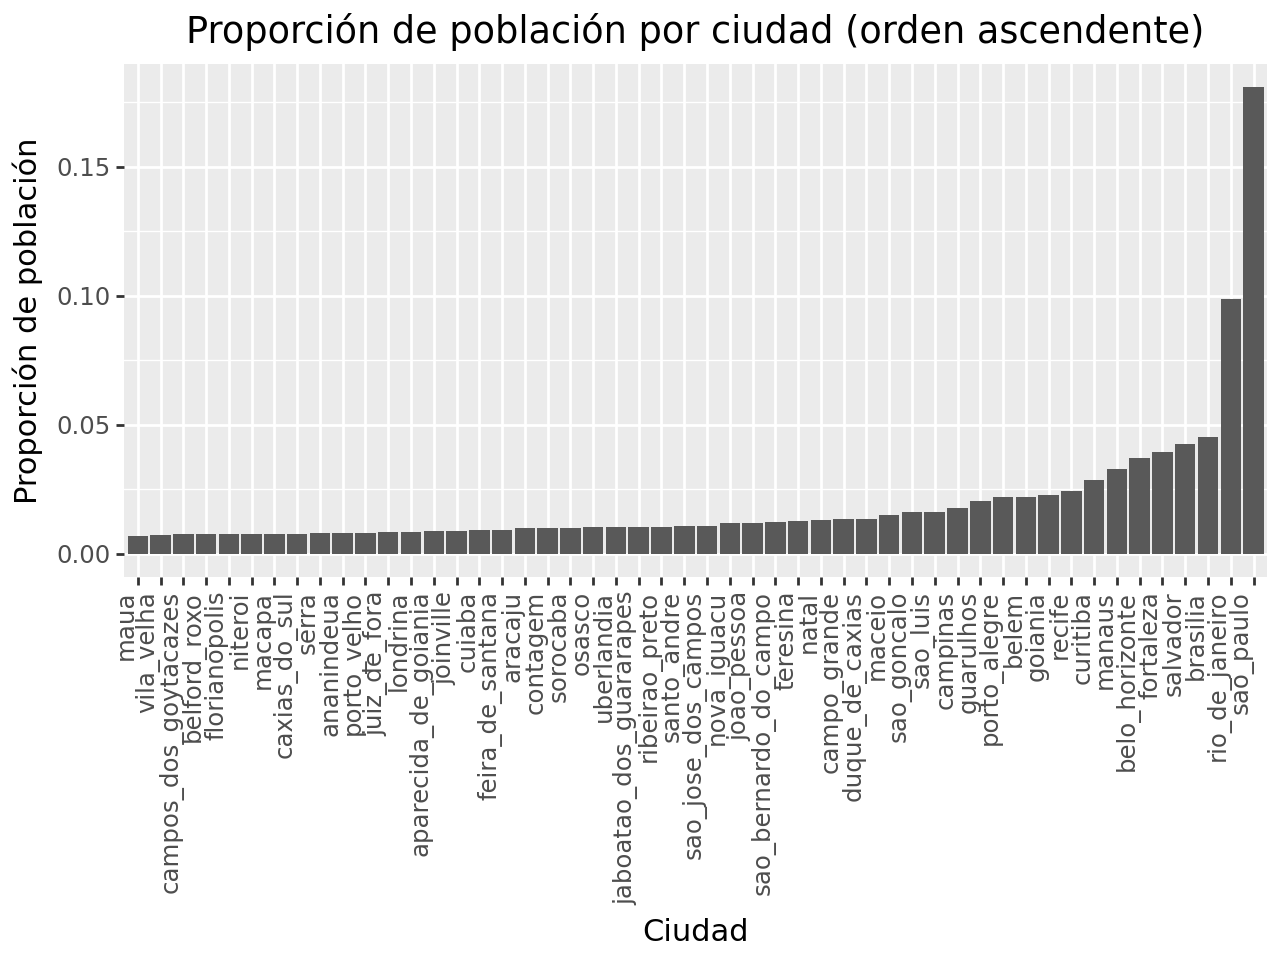

In [39]:
## ggplot de la proporción de población por ciudad


# Refactorizamos usando Polars para mantener la eficiencia y claridad en la manipulación de datos.
# Ordenamos las ciudades por su proporción de población y convertimos a pandas solo para graficar.
pop_pd = (
    pop_por_ciudad
    .sort("prop_population")
    .with_columns(
        pl.col("city").cast(pl.Categorical)
    )
)

(
    ggplot(
        pop_pd,
        aes(x="city", y="prop_population")
    )
    + geom_bar(stat="identity")
    + theme(axis_text_x=element_text(rotation=90, hjust=1))
    + labs(title="Proporción de población por ciudad (orden ascendente)", x="Ciudad", y="Proporción de población")
)

### La Fórmula Final Explicada

Para diseñar el experimento sintético perfecto, necesitamos encontrar la combinación de ciudades que mejor represente el comportamiento promedio del mercado antes de cualquier intervención. Esta ecuación es el "corazón" del diseño y busca resolver un problema de optimización cuadrática con restricciones:

$$
\min_{w, v} \| \mu_{pre} - Y_{pre} w - \alpha_0 \|^2 + \| \mu_{pre} - Y_{pre} v - \beta_0 \|^2
$$

Bajo las siguientes condiciones conceptuales:

| Término | Significado en "Lenguaje Humano" |
| :--- | :--- |
| $\min_{w, v}$ | **Búsqueda Óptima:** "Encuentra la mejor combinación de pesos para el Grupo de Tratamiento ($w$) y el Grupo de Control ($v$)." |
| $\mu_{pre} - Y_{pre} w$ | **Minimización del Error:** "Haz que la diferencia entre el promedio real del mercado ($\mu_{pre}$) y mi grupo de ciudades seleccionadas ($Y_{pre} w$) sea lo más cercana a cero posible." |
| $\alpha_0, \beta_0$ | **Ajuste de Nivel (Interceptos):** Permiten que los grupos tengan diferentes volúmenes absolutos de descargas, siempre y cuando sigan la misma **tendencia** (paralelismo). |
| $\sum w_i = 1$ | **Normalización:** "Asegúrate de que la suma de todas las participaciones de las ciudades sea exactamente el 100%." |
| $w_i v_i = 0$ | **Exclusividad Mutua:** "Si una ciudad está en el grupo de tratamiento, tiene terminantemente prohibido estar en el grupo de control." |
| $\|w\|_0 \leq m$ | **Restricción de Dispersión (Sparsity):** "No me permitas elegir más de $m$ ciudades para el tratamiento" (para mantener el experimento manejable y dentro de presupuesto). |



## Trying a Random Set of Treated Units
